In [1]:
# Load necessary library
library(fs)
library("ggplot2")
install.packages("tidyverse")
library(dplyr)
library("tidyverse")
# Required library for rolling mean
library(zoo)  # Install if needed: install.packages("zoo")
# Assuming 'dot_plot_data' is wide format, create a heatmap (for a grid of values)
library(reshape2,lib.loc="/data/proj2/home/students/u.srinivasan/R/library")
library(RColorBrewer)


Warning message:
“unable to access index for repository https://cran.r-project.org/src/contrib:
  cannot open URL 'https://cran.r-project.org/src/contrib/PACKAGES'”
Warning message:
“package ‘tidyverse’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::la

Kingman const popsize

In [ ]:
# Define the base directory for containing all hidden states replicates.
# This directory should be at least 2 dirs deep and vary in mutation rate
kingman_dir1 <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman"

# List directories in kingman_dir1 that are exactly two levels deep
kingman_subdirs1 <- list.dirs(kingman_dir1, recursive = TRUE, full.names = TRUE)
kingman_subdirs1 <- kingman_subdirs1[sapply(strsplit(kingman_subdirs1, "/"), length) == length(strsplit(kingman_dir1, "/")[[1]]) + 2]

# Initialize a list to store kingman directories categorized by mutation rate
kingman_dirs_by_mutation_rate <- list()

# Loop through each kingman directory and categorize based on mutation rate
for (kingman_dir in kingman_subdirs1) {
  # Extract the second-to-last directory as the mutation rate identifier
  mutation_rate_dir <- basename(dirname(kingman_dir))
  print(mutation_rate_dir)
  # Store the directories under the mutation rate
  if (!is.null(kingman_dirs_by_mutation_rate[[mutation_rate_dir]])) {
    kingman_dirs_by_mutation_rate[[mutation_rate_dir]] <- c(kingman_dirs_by_mutation_rate[[mutation_rate_dir]], kingman_dir)
  } else {
    kingman_dirs_by_mutation_rate[[mutation_rate_dir]] <- list(kingman_dir)
  }
}

# Format the output for better readability
kingman_dirs_by_mutation_rate


[1] "fixed_r"
[1] "fixed_r"
[1] "fixed_r"
[1] "free_r"
[1] "free_r"
[1] "free_r"


$fixed_r
$fixed_r[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/fixed_r/m1e-10"

$fixed_r[[2]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/fixed_r/m1e-7"

$fixed_r[[3]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/fixed_r/m1e-8"


$free_r
$free_r[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/free_r/m1e-10"

$free_r[[2]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/free_r/m1e-7"

$free_r[[3]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/free_r/m1e-8"

In [4]:
# Format the kingman directories by mutation rate
formatted_kingman_dirs <- lapply(names(kingman_dirs_by_mutation_rate), function(mutation_rate) {
  list(
    mutation_rate = mutation_rate,
    kingman_dirs = kingman_dirs_by_mutation_rate[[mutation_rate]]
  )
})

# Display the categorized kingman directories
print("Kingman Directories Categorized by Mutation Rate:")
print(formatted_kingman_dirs)



[1] "Kingman Directories Categorized by Mutation Rate:"
[[1]]
[[1]]$mutation_rate
[1] "fixed_r"

[[1]]$kingman_dirs
[[1]]$kingman_dirs[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/fixed_r/m1e-10"

[[1]]$kingman_dirs[[2]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/fixed_r/m1e-7"

[[1]]$kingman_dirs[[3]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/fixed_r/m1e-8"



[[2]]
[[2]]$mutation_rate
[1] "free_r"

[[2]]$kingman_dirs
[[2]]$kingman_dirs[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/free_r/m1e-10"

[[2]]$kingman_dirs[[2]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/free_r/m

In [4]:
# Initialize a list to store the paths of .rds files from kingman directories
rds_files_list <- list()

# Loop through each formatted kingman directory group
for (i in seq_along(formatted_kingman_dirs)) {
  # Get the mutation rate (kingman directory identifier)
  mutation_rate <- formatted_kingman_dirs[[i]]$mutation_rate
  
  # Get the kingman directories
  kingman_dirs <- formatted_kingman_dirs[[i]]$kingman_dirs
  
  # Collect the .rds files from each kingman directory
  rds_files_kingman <- unlist(lapply(kingman_dirs, function(kingman_dir) {
    list.files(path = kingman_dir, pattern = "\\.rds$", full.names = TRUE)
  }))
  
  # Store the results in the list
  rds_files_list[[mutation_rate]] <- rds_files_kingman
}

# Print the list of .rds files, categorized by mutation rate
print(rds_files_list)



$fixed_r
 [1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/fixed_r/m1e-10/Kingman_bottleneck_rep0_m1e-10_ratio999.9999999999999_rs1525225.vcf.rds"
 [2] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/fixed_r/m1e-10/Kingman_bottleneck_rep1_m1e-10_ratio999.9999999999999_rs1525226.vcf.rds"
 [3] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/fixed_r/m1e-10/Kingman_bottleneck_rep3_m1e-10_ratio999.9999999999999_rs1525228.vcf.rds"
 [4] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/fixed_r/m1e-10/Kingman_bottleneck_rep4_m1e-10_ratio999.9999999999999_rs1525229.vcf.rds"
 [5] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman/fixe

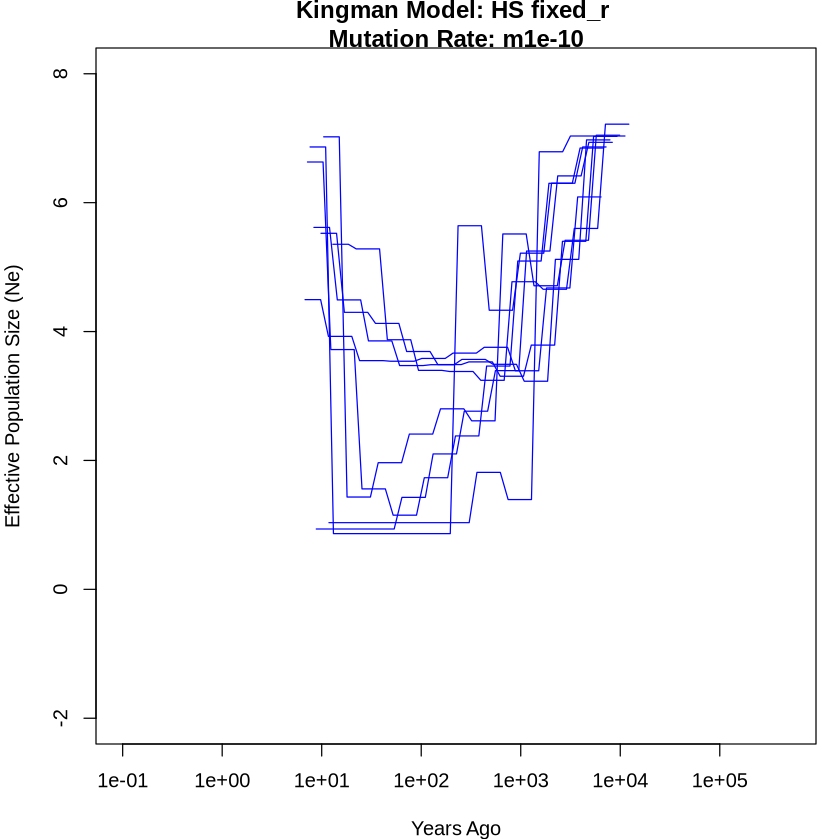

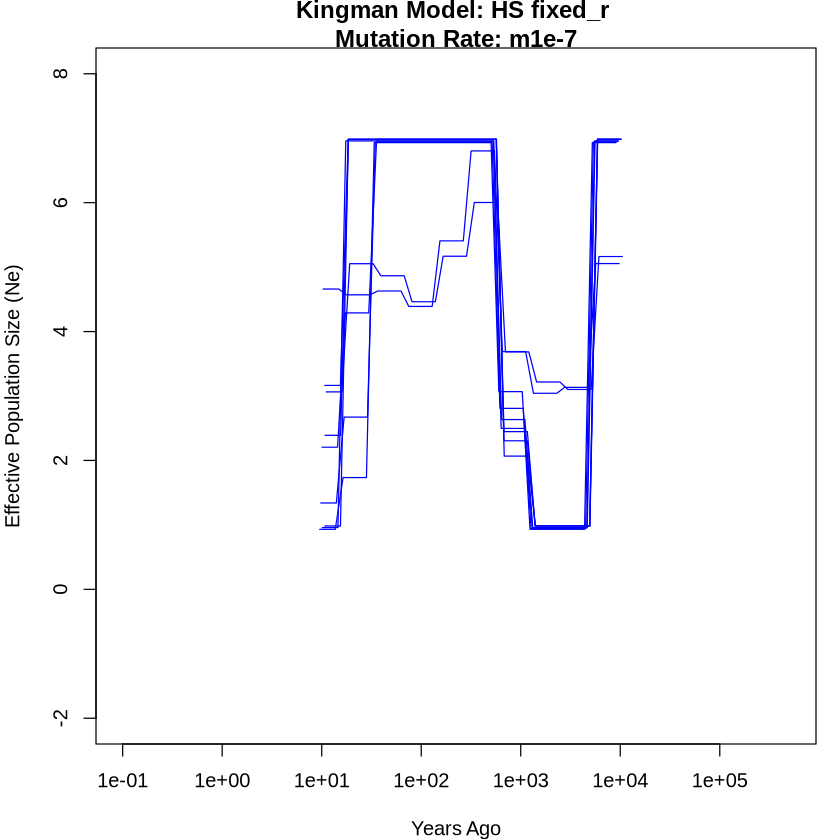

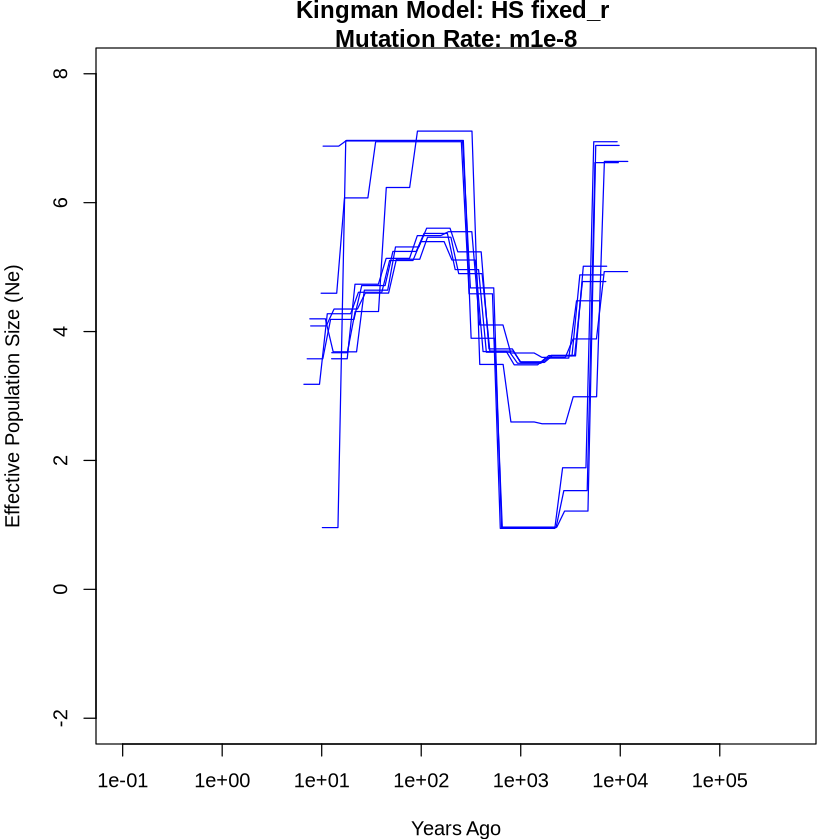

In [5]:
# Constants
mu <- 1e-06
gen_times <- 0.16

# Initialize a nested list to store data grouped by HS and mutation rate
hs_mu_grouped_data <- list()

# Process 'kingman' files
for (j in seq_along(rds_files_list[[1]])) {
  kingman_dir <- rds_files_list[[1]][j]
  
  # Extract the HS, mutation rate (mu) from the directory name
  path_components <- unlist(strsplit(kingman_dir, "/"))
  hs_identifier <- path_components[length(path_components) - 2]    # HS identifier (e.g., "HS_20")
  mutr_identifier <- path_components[length(path_components) - 1] # Mutation rate (e.g., "1e-07")
  mutr_numeric <- as.numeric(sub(".*(\\d+e[+-]?\\d+).*", "\\1", mutr_identifier))
  #print(mutr_numeric)
  if (file.exists(kingman_dir)) {
    data_esmc <- readRDS(kingman_dir)  # Read the .rds file

    # Perform calculations
    Ne_t <- data_esmc$Xi
    Ne <- mean(data_esmc$mu / mutr_numeric)
    alpha <- 2  # Set fixed alpha to 2 for Kingman model
    # Calculate years ago and log10 of Ne
    data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
    data_esmc$Ne <- log10(Ne_t * Ne)
    
    # Create a data frame for this file
    df <- data.frame(
      years_ago = data_esmc$years_ago,
      Ne = data_esmc$Ne,
      alpha_sim = alpha,
      alpha_inf = alpha  # Inferred alpha is also 2
    )
    
    # Group data by HS and mutation rate
    if (is.null(hs_mu_grouped_data[[hs_identifier]])) {
      hs_mu_grouped_data[[hs_identifier]] <- list()
    }
    if (is.null(hs_mu_grouped_data[[hs_identifier]][[mutr_identifier]])) {
      hs_mu_grouped_data[[hs_identifier]][[mutr_identifier]] <- list()
    }
    hs_mu_grouped_data[[hs_identifier]][[mutr_identifier]] <- append(
      hs_mu_grouped_data[[hs_identifier]][[mutr_identifier]],
      list(df)
    )
  } else {
    warning(paste("Kingman directory does not exist:", kingman_dir))
  }
}

# Loop through each HS and mutation rate group and create plots
for (hs in names(hs_mu_grouped_data)) {
  for (mutr in names(hs_mu_grouped_data[[hs]])) {
    # Get the data frames for this HS and mutation rate group
    kingman_lines <- hs_mu_grouped_data[[hs]][[mutr]]
    
    # Set up 2x2 layout for plotting
    par( mar = c(4, 4, 2, 1), bg = "white")  # 2x2 layout for subplots
    
    # Plot for the current HS and mutation rate combination
    # Create an empty plot
    plot(NULL, xlim = c(0.1, 500000), ylim = c(-2, 8),
         xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
         main = paste("Kingman Model: HS", hs, "\nMutation Rate:", mutr),
         log = "x", col = "black")
    
    # Plot the line for the Kingman model (alpha = 2) for this mutation rate and HS
    for (i in seq_along(kingman_lines)) {
      lines(kingman_lines[[i]]$years_ago, kingman_lines[[i]]$Ne, 
            type = "l", lty = 1, col = "blue")  # Plot with a fixed color
    }
    

  }
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1), bg = "white")



In [6]:
kingman_lines

years_ago,Ne,alpha_sim,alpha_inf
<dbl>,<dbl>,<dbl>,<dbl>
0.000000,4.5949981,2,2
9.870318,4.5949981,2,2
11.819457,4.5949981,2,2
14.153502,4.5949981,2,2
16.948462,6.0739612,2,2
20.295356,6.0739612,2,2
24.303177,6.0739612,2,2
29.102442,6.0739612,2,2
34.849441,6.9455798,2,2


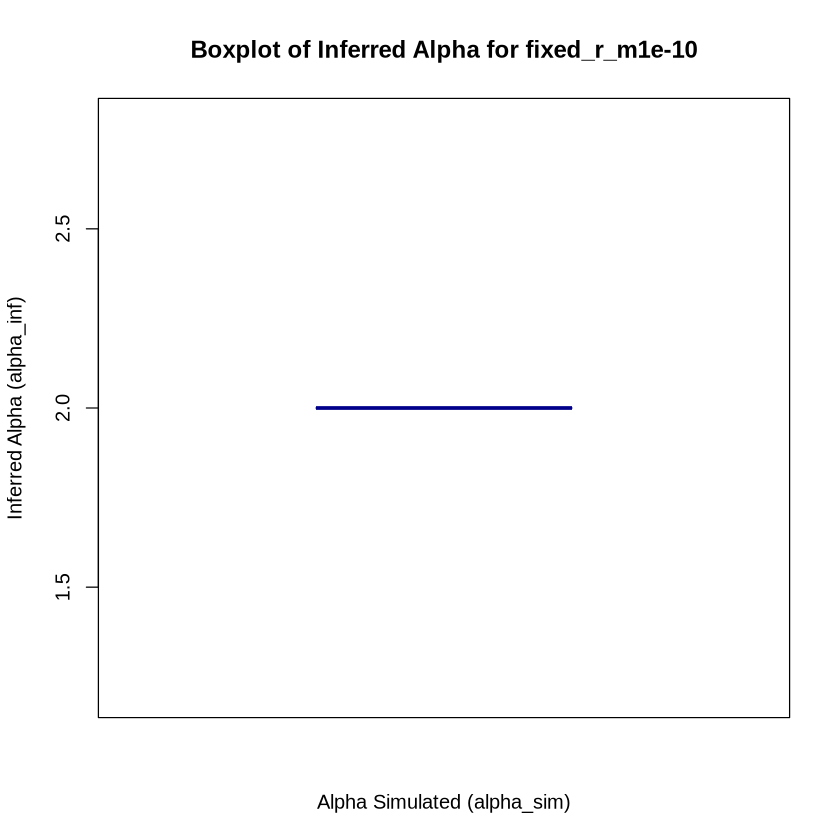

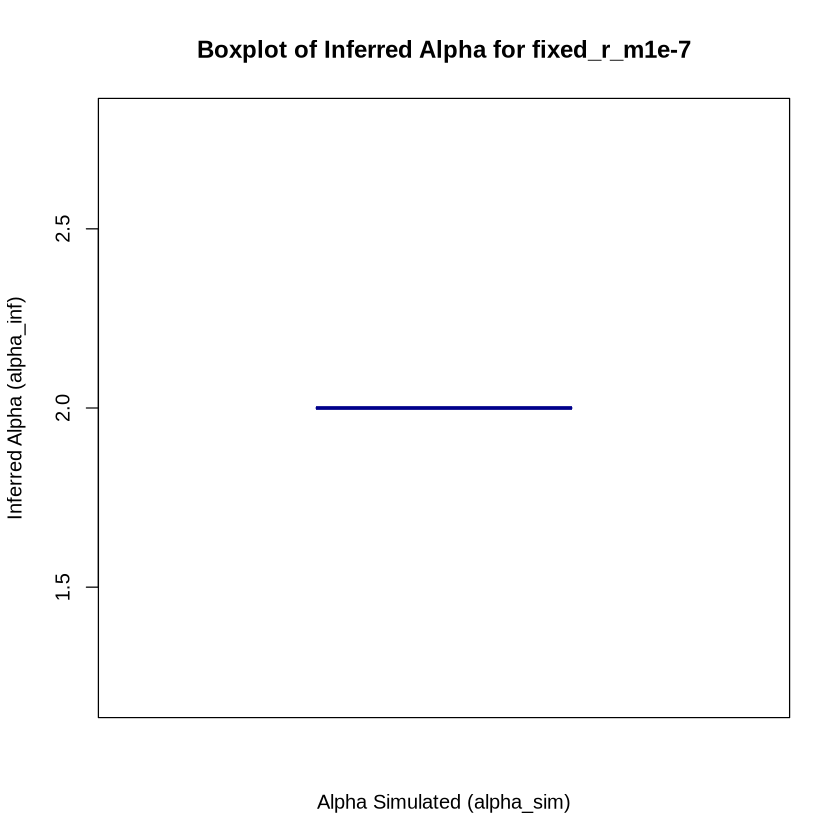

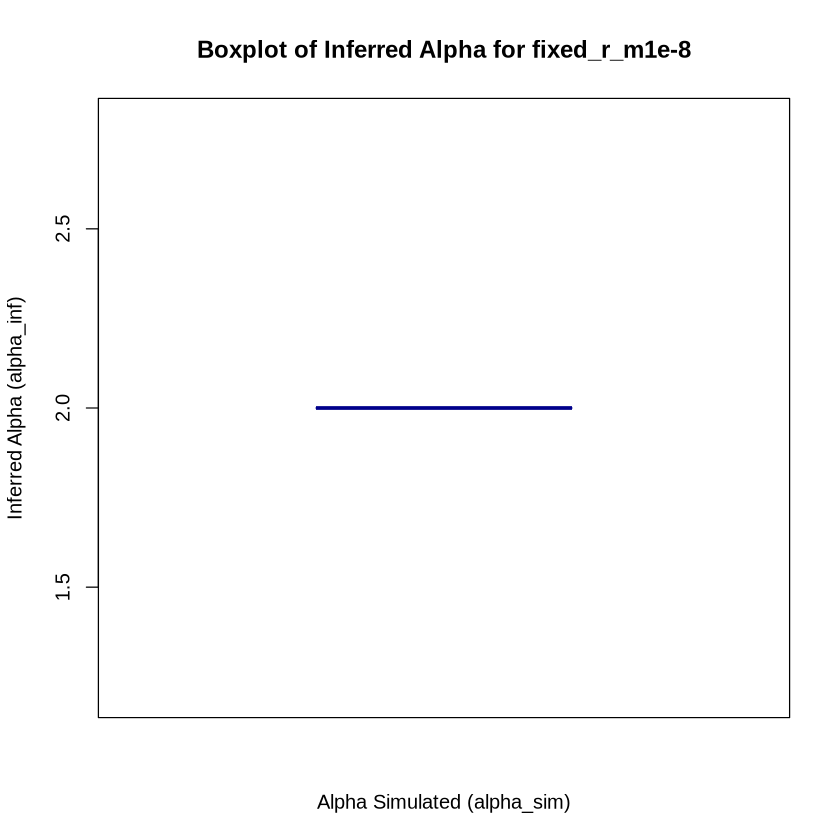

In [7]:
# Initialize a list to collect alpha_sim and alpha_inf for each HS and mutation rate combination
alpha_data <- list()

# Loop through each HS and mutation rate group to collect alpha_sim and alpha_inf
for (hs in names(hs_mu_grouped_data)) {
  for (mutr in names(hs_mu_grouped_data[[hs]])) {
    # Get the data frames for this HS and mutation rate group
    kingman_lines <- hs_mu_grouped_data[[hs]][[mutr]]

    # Initialize vectors to store alpha_sim and alpha_inf
    alpha_sim_values <- numeric()
    alpha_inf_values <- numeric()
    
    # Loop through each line in kingman_lines and extract alpha_sim and alpha_inf
    for (entry in kingman_lines) {
      alpha_sim_values <- c(alpha_sim_values, entry$alpha_sim)
      alpha_inf_values <- c(alpha_inf_values, entry$alpha_inf)
    }
    
    # Store the values in the alpha_data list
    alpha_data[[paste(hs, mutr, sep = "_")]] <- data.frame(
      alpha_sim = alpha_sim_values,
      alpha_inf = alpha_inf_values
    )
  }
}

# Set background color to white for the plots
par(bg = "white")

# Loop through each HS and mutation rate group and create a boxplot
for (hs in names(alpha_data)) {
  plot_data <- alpha_data[[hs]]
  
  # Set up boxplot for alpha_sim vs alpha_inf
  boxplot(alpha_inf ~ alpha_sim, data = plot_data,
          xlab = "Alpha Simulated (alpha_sim)",
          ylab = "Inferred Alpha (alpha_inf)",
          main = paste("Boxplot of Inferred Alpha for", hs),
          col = "lightblue", border = "darkblue")
}

# Reset layout to default for any further plots
par(bg = "white")



Beta const popsize

In [1]:
# Define the base directory for the beta directories
beta_dir1 <- ""

# List directories in beta_dir1 that are exactly two levels deep
beta_subdirs1 <- list.dirs(beta_dir1, recursive = TRUE, full.names = TRUE)
beta_subdirs1 <- beta_subdirs1[sapply(strsplit(beta_subdirs1, "/"), length) == length(strsplit(beta_dir1, "/")[[1]]) + 2]

# Initialize a list to store beta directories categorized by mutation rate
beta_dirs_by_mutation_rate <- list()

# Loop through each beta directory and categorize based on mutation rate
for (beta_dir in beta_subdirs1) {
  # Extract the second-to-last directory as the mutation rate identifier
  mutation_rate_dir <- basename(dirname(beta_dir))
  
  # Store the directories under the mutation rate
  if (!is.null(beta_dirs_by_mutation_rate[[mutation_rate_dir]])) {
    beta_dirs_by_mutation_rate[[mutation_rate_dir]] <- c(beta_dirs_by_mutation_rate[[mutation_rate_dir]], beta_dir)
  } else {
    beta_dirs_by_mutation_rate[[mutation_rate_dir]] <- list(beta_dir)
  }
}

# Format the output for better readability


In [2]:
formatted_beta_dirs <- lapply(names(beta_dirs_by_mutation_rate), function(mutation_rate) {
  list(
    mutation_rate = mutation_rate,
    beta_dirs = beta_dirs_by_mutation_rate[[mutation_rate]]
  )
})

# Display the categorized beta directories
print("Beta Directories Categorized by Mutation Rate:")
print(formatted_beta_dirs)


[1] "Beta Directories Categorized by Mutation Rate:"
[[1]]
[[1]]$mutation_rate
[1] "m1e-06"

[[1]]$beta_dirs
[[1]]$beta_dirs[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/beta_3haps_10mb_const/m1e-06/alpha1.3"

[[1]]$beta_dirs[[2]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/beta_3haps_10mb_const/m1e-06/alpha1.5"

[[1]]$beta_dirs[[3]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/beta_3haps_10mb_const/m1e-06/alpha1.7"

[[1]]$beta_dirs[[4]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/beta_3haps_10mb_const/m1e-06/alpha1.9"



[[2]]
[[2]]$mutation_rate
[1] "m1e-07"

[[2]]$beta_dirs
[[2]]$beta_dirs[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_f

In [3]:
# Initialize a list to store the paths of .rds files from beta directories
rds_files_list <- list()

# Loop through each formatted beta directory group
for (i in seq_along(formatted_beta_dirs)) {
  # Get the mutation rate (beta directory identifier)
  mutation_rate <- formatted_beta_dirs[[i]]$mutation_rate
  
  # Get the beta directories
  beta_dirs <- formatted_beta_dirs[[i]]$beta_dirs
  
  # Collect the .rds files from each beta directory
  rds_files_beta <- unlist(lapply(beta_dirs, function(beta_dir) {
    list.files(path = beta_dir, pattern = "\\.rds$", full.names = TRUE)
  }))
  
  # Store the results in the list
  rds_files_list[[mutation_rate]] <- rds_files_beta
}

# Print the list of .rds files, categorized by mutation rate
print(rds_files_list)


$`m1e-06`
 [1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/beta_3haps_10mb_const/m1e-06/alpha1.3/Beta_rep0_m1e-06_ratio0.1_rs152423716.vcf.rds"
 [2] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/beta_3haps_10mb_const/m1e-06/alpha1.3/Beta_rep1_m1e-06_ratio0.1_rs152423717.vcf.rds"
 [3] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/beta_3haps_10mb_const/m1e-06/alpha1.3/Beta_rep2_m1e-06_ratio0.1_rs152423718.vcf.rds"
 [4] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/beta_3haps_10mb_const/m1e-06/alpha1.3/Beta_rep3_m1e-06_ratio0.1_rs152423719.vcf.rds"
 [5] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/beta_3haps_10mb_const/m1e-06/alpha1.3/Be

In [13]:
# Constants
mu <- 1e-06
gen_times <-0.16

# Initialize a list to store individual data frames with hierarchical structure
individual_data_frames <- vector("list", length(rds_files_list))


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[1]] <- list()
  

  # Process 'beta' files
  for (j in seq_along(rds_files_list[[1]])) {
    beta_dir <- rds_files_list[[1]][j]
    #split path
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      alpha<-data_esmc$alpha
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[1]][[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha_sim=as.character(second_last_component),
        alpha_inf=alpha
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}



In [14]:
# Create a color palette for the alpha values
alpha_values <- unique(unlist(lapply(individual_data_frames[[1]], function(df) df$alpha_sim)))
colors <- rainbow(length(alpha_values))  # Generate colors for each alpha
alpha_values


[1] "alpha1.3" "alpha1.5" "alpha1.7" "alpha1.9"

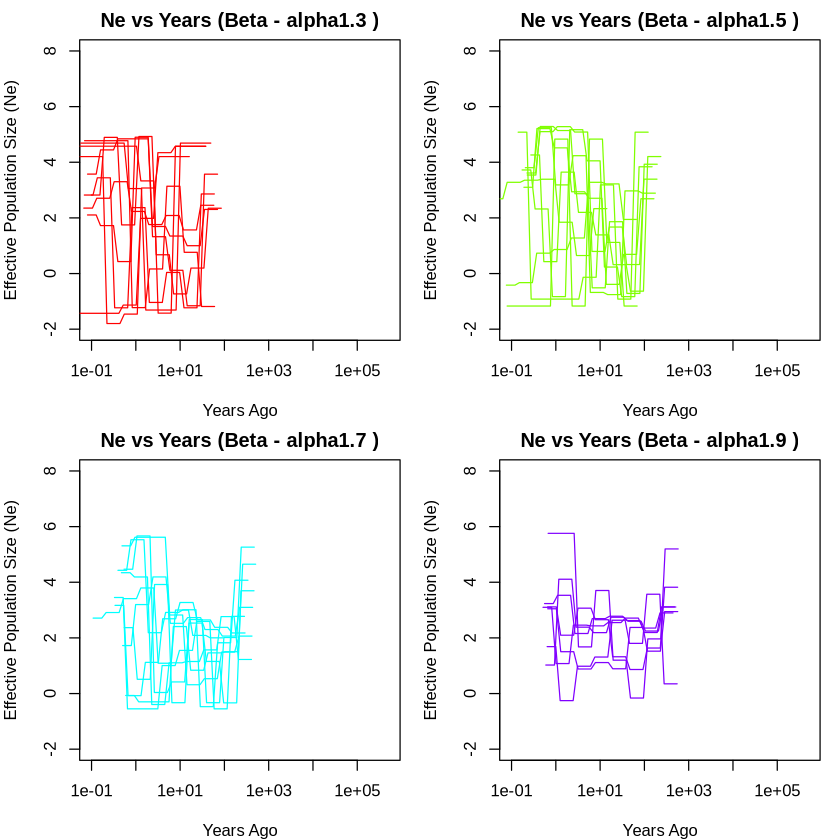

In [15]:
# Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1), bg = "white")  # White background for the plots

# Check that alpha_values and colors are compatible
if (length(alpha_values) != length(colors)) {
  stop("Length of alpha_values does not match the length of colors.")
}

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  
  # Set up an empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(-2, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years (Beta -", alpha, ")"),
       log = "x", col = "black")
  
  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[1]], function(df) {
    if (!is.null(df) && df$alpha_sim[1] == alpha) {  # Ensure df is not NULL
      return(df)
    } else {
      return(NULL)
    }
  })

  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries
  
  # If beta_lines is empty, skip the plot for this alpha
  if (length(beta_lines) > 0) {
    # Plot each line for the current alpha
    for (i in seq_along(beta_lines)) {
      lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
            type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
    }
  } else {
    message("No data found for alpha: ", alpha)
  }


}

# Reset layout to default for any further plots
par(mfrow = c(1, 1), bg = "white")



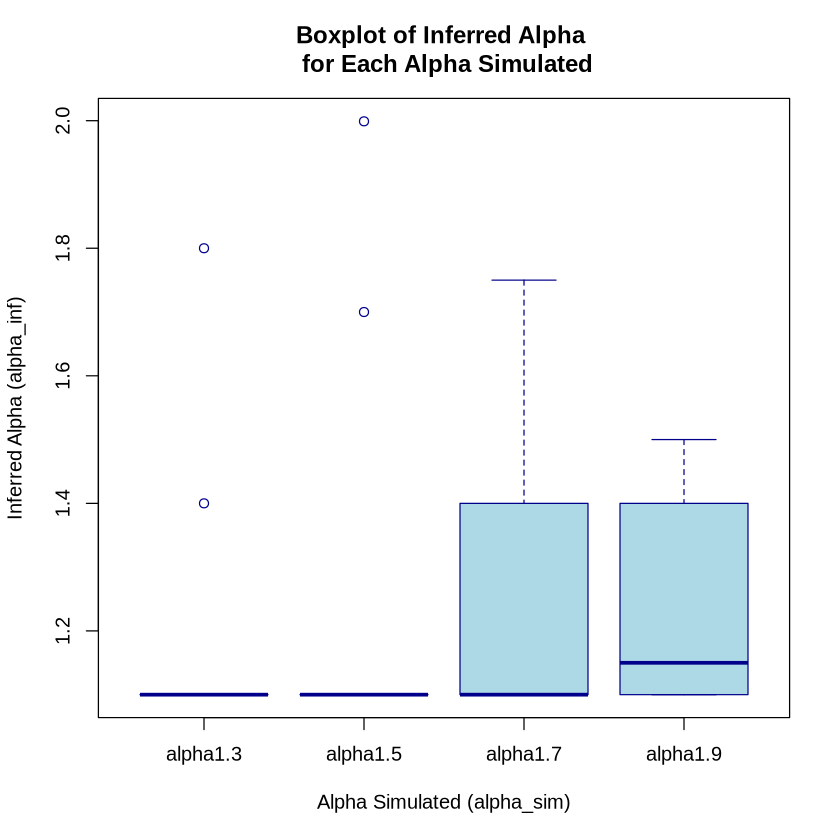

In [16]:
# Initialize a list to store alpha_inf values grouped by alpha_sim
alpha_data <- list()

# Loop through each entry in individual_data_frames to extract alpha_sim and alpha_inf
for (entry in individual_data_frames[[1]]) {
  if (!is.null(entry$alpha_sim) && !is.null(entry$alpha_inf)) {
    alpha_sim <- entry$alpha_sim[1]  # Get the alpha_sim (assuming it’s consistent within each data frame)
    alpha_inf <- entry$alpha_inf[1]  # Get the alpha_inf for this specific simulation
    
    # Append the alpha_inf value to the appropriate alpha_sim group
    if (alpha_sim %in% names(alpha_data)) {
      alpha_data[[alpha_sim]] <- c(alpha_data[[alpha_sim]], alpha_inf)
    } else {
      alpha_data[[alpha_sim]] <- alpha_inf
    }
  }
}

# Convert the list into a data frame suitable for plotting
plot_data <- stack(alpha_data)
names(plot_data) <- c("alpha_inf", "alpha_sim")  # Rename columns for clarity

# Set background color to white
par(bg = "white")

# Create the boxplot
boxplot(alpha_inf ~ alpha_sim, data = plot_data,
        xlab = "Alpha Simulated (alpha_sim)",
        ylab = "Inferred Alpha (alpha_inf)",
        main = paste("Boxplot of Inferred Alpha", "\n", "for Each Alpha Simulated"),
        col = "lightblue", border = "darkblue")




m1e-07

In [ ]:
# Constants
mu <- 1e-07
gen_times <-0.16


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[2]] <- list()
 
  
  # Process 'beta' files
  for (j in seq_along(rds_files_list[[1]])) {
    beta_dir <- rds_files_list[[1]][j]
    #split path
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      alpha<-data_esmc$alpha
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[2]][[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha_sim=as.character(second_last_component),
        alpha_inf=alpha
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }

}


No data found for alpha: alpha1.3

No data found for alpha: alpha1.5



No data found for alpha: alpha1.9



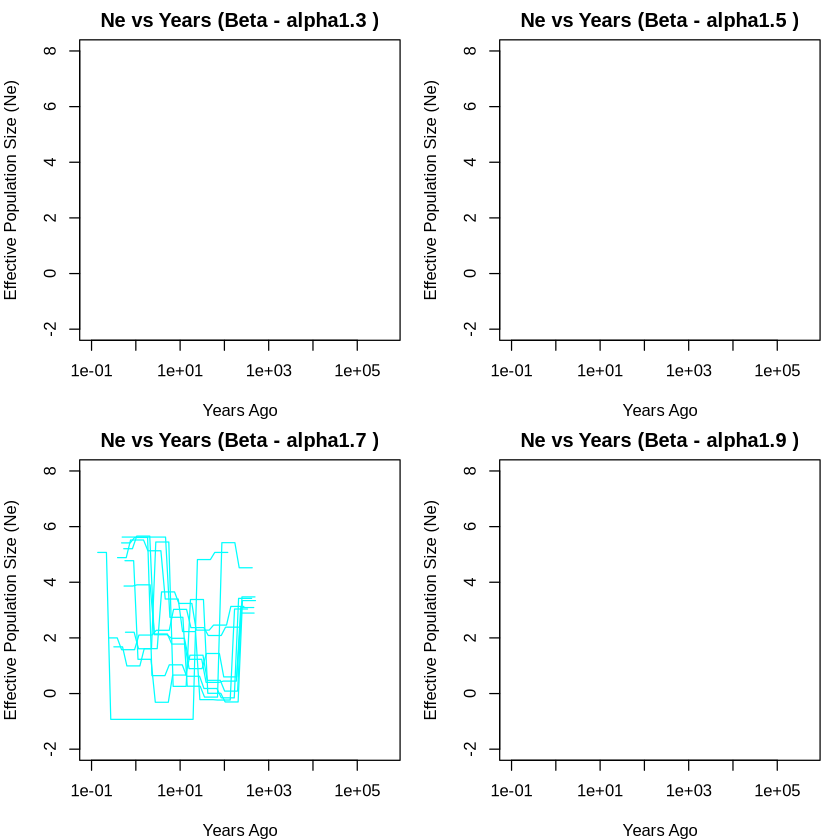

In [11]:
# Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1), bg = "white")  # White background for the plots

# Check that alpha_values and colors are compatible
if (length(alpha_values) != length(colors)) {
  stop("Length of alpha_values does not match the length of colors.")
}

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  
  # Set up an empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(-2, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years (Beta -", alpha, ")"),
       log = "x", col = "black")
  
  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[2]], function(df) {
    if (!is.null(df) && df$alpha_sim[1] == alpha) {  # Ensure df is not NULL
      return(df)
    } else {
      return(NULL)
    }
  })

  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries
  
  # If beta_lines is empty, skip the plot for this alpha
  if (length(beta_lines) > 0) {
    # Plot each line for the current alpha
    for (i in seq_along(beta_lines)) {
      lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
            type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
    }
  } else {
    message("No data found for alpha: ", alpha)
  }


}

# Reset layout to default for any further plots
par(mfrow = c(1, 1), bg = "white")


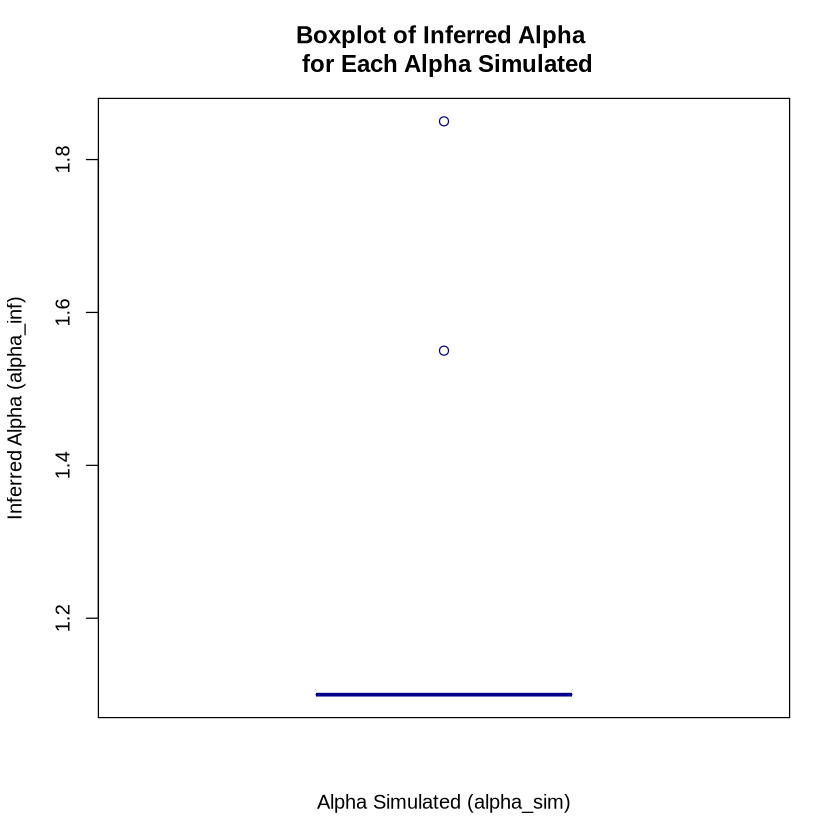

In [12]:
# Initialize a list to store alpha_inf values grouped by alpha_sim
alpha_data <- list()

# Loop through each entry in individual_data_frames to extract alpha_sim and alpha_inf
for (entry in individual_data_frames[[2]]) {
  if (!is.null(entry$alpha_sim) && !is.null(entry$alpha_inf)) {
    alpha_sim <- entry$alpha_sim[1]  # Get the alpha_sim (assuming it’s consistent within each data frame)
    alpha_inf <- entry$alpha_inf[1]  # Get the alpha_inf for this specific simulation
    
    # Append the alpha_inf value to the appropriate alpha_sim group
    if (alpha_sim %in% names(alpha_data)) {
      alpha_data[[alpha_sim]] <- c(alpha_data[[alpha_sim]], alpha_inf)
    } else {
      alpha_data[[alpha_sim]] <- alpha_inf
    }
  }
}

# Convert the list into a data frame suitable for plotting
plot_data <- stack(alpha_data)
names(plot_data) <- c("alpha_inf", "alpha_sim")  # Rename columns for clarity

# Set background color to white
par(bg = "white")

# Create the boxplot
boxplot(alpha_inf ~ alpha_sim, data = plot_data,
        xlab = "Alpha Simulated (alpha_sim)",
        ylab = "Inferred Alpha (alpha_inf)",
        main = paste("Boxplot of Inferred Alpha", "\n", "for Each Alpha Simulated"),
        col = "lightblue", border = "darkblue")

